# Exploring Library Catalogues as Data
## Part II. Data analysis and visualisation
### Import the necessary libraries

In this part we work with the data frame, so we do not need the PyMARC library from this point.

In [2]:
%pip install pandas matplotlib matplotlib-venn numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import re
import numpy as np

### Import from the previously created CSV files

For this example we'll treat two Yale shards as two different catalogues. In the previous part we already saved the to CSV files so we import them into data frames.

In [4]:
df_a = pd.read_csv('bib_20250706_full_000_00.csv')
df_b = pd.read_csv('bib_20250706_full_000_01.csv')

print(f'Catalogue A: {len(df_a)} records')
print(f'Catalogue B: {len(df_b)} records')

Catalogue A: 200000 records
Catalogue B: 200000 records


### Asking a question of the collection

We now have a DataFrame, which means we can start asking what the catalogue contains: publication date distribution, author concentration, language coverage, and so on. We'll work through one example, counting records that use subject headings the Library of Congress has recently revised.

LCSH is a living vocabulary. Headings get added, retired, and renamed as cataloguing practice evolves; the Library of Congress publishes the [approved changes](https://classweb.org/approved-subjects/) on a rolling basis. Notable examples: "Aliens" became "Noncitizens", "Slaves" became "Enslaved persons", and "McKinley, Mount" became "Denali, Mount". How many records in our data still carry the older or revised forms?

Pandas' `.str.contains()` filters a string column by whether each value contains a substring; calling `.sum()` on the resulting True/False Series counts the matches:

In [5]:
lc_changes = ['McKinley, Mount', 'Enslaved persons', 'Noncitizen']

for change in lc_changes:
    count = df_a['subjects'].str.contains(change, na=False).sum()
    print(f'{change}: {count} records')

McKinley, Mount: 1 records
Enslaved persons: 51 records
Noncitizen: 25 records


_You should see_ a count per term, some common, others rare or zero depending on what this shard contains and which form its records use.

A caveat: this counts substring matches, so it tells you a term is present, not whether it is current or why a cataloguer chose it. The technique is general, though: `.str.contains()` plus `.sum()` counts matches for any pattern in any column.

### Comparing two datasets

Looking at one dataset is useful. Comparing two is often more useful: *how does another catalogue describe the same kind of material?*

A librarian benchmarking her catalogue against a national bibliography asks this to find cataloguing gaps. A researcher studying vocabulary change asks it to see how practice differs across institutions. The underlying computational move is the same: filter both datasets by a topic, then compare the subject headings each side uses.

To compare them, we need two more functions.

##### Function 2: `headings_matching`

This function takes a DataFrame and a keyword, and returns the set of subject headings used on records that mention that keyword.

In [6]:
def headings_matching(df, keyword):
    """Return the set of subject headings used on records whose
    subjects column contains the keyword."""

    matching = df[df['subjects'].str.contains(keyword, na=False)]

    headings = set()
    for subjects_str in matching['subjects']:
        headings.update(subjects_str.split('|'))

    return headings

The function does three things in order: filter the DataFrame to rows matching the keyword, split each row's pipe-separated subjects string into individual headings, and collect them into a set. A set is the right data structure here because it removes duplicates automatically (the same heading appearing in many records counts once) and because we'll want to use set operations to compare two of them.

Try it:

In [7]:
headings_a = headings_matching(df_a, 'Immigra')
headings_b = headings_matching(df_b, 'Immigra')

print(f'Catalogue A uses {len(headings_a)} distinct headings on immigration records')
print(f'Catalogue B uses {len(headings_b)} distinct headings on immigration records')

Catalogue A uses 27 distinct headings on immigration records
Catalogue B uses 35 distinct headings on immigration records


**You should see** two counts. These are the *vocabularies* each catalogue uses around immigration: every distinct subject heading that appears on a record mentioning "Immigra".

##### Function 3: `compare_sets`

This function takes two sets and returns a dictionary describing how they overlap: what's in both, what's only in the first, what's only in the second.

In [8]:
def compare_sets(set_x, set_y):
    """Compare two sets. Return a dict with three keys:
    shared (in both), only_in_x, and only_in_y."""

    return {
        'shared':    set_x & set_y,
        'only_in_x': set_x - set_y,
        'only_in_y': set_y - set_x,
    }

The function is short because Python's set operators do the heavy lifting: `&` returns the intersection, and `-` returns the difference.

Putting the pieces together:

In [9]:
result = compare_sets(headings_a, headings_b)

print(f'Shared headings:     {len(result["shared"])}')
print(f'Only in catalogue A: {len(result["only_in_x"])}')
print(f'Only in catalogue B: {len(result["only_in_y"])}')

print('\nSample headings only in catalogue A:')
for h in sorted(result['only_in_x'])[:5]:
    print(f'  - {h}')

Shared headings:     6
Only in catalogue A: 21
Only in catalogue B: 29

Sample headings only in catalogue A:
  - Acculturation.
  - American fiction
  - Americanization.
  - Art, American
  - Artists


**You should see** counts followed by a few example headings unique to catalogue A. The asymmetric differences (the "only in" sets) are usually the interesting numbers, they tell you where the two catalogues diverge in vocabulary.

Each function is useful on its own. `compare_sets` works on any two sets, not just sets of headings. `headings_matching` works on any DataFrame with a pipe-separated `subjects` column, not just Yale's. If you wanted to compare three catalogues instead of two, or compare authors instead of subjects, you'd reuse most of these pieces unchanged.

We now have three numbers describing how two catalogues overlap: what they share, and what's unique to each side. Numbers like these are easier to grasp at a glance when they're drawn rather than printed, which is where visualisation comes in.

#### Visualization: Creating a Venn diagram

A good data visualization that summarises numbers helps someone to realise trends and important features of a collection of data. [Above](#function-3-compare_sets) we saw how to calculate the difference of two sets of subject headings. Based on previously defined functions our code was this:

In [10]:
headings_a = headings_matching(df_a, 'Immigra')
headings_b = headings_matching(df_b, 'Immigra')

result = compare_sets(headings_a, headings_b)

The `result` is a dictionary with three keys each containing a set. The keys are `shared`, `only_in_x` and `only_in_y`. We would like to display two circles that have an intersection if they share subjects, and are proportional to the number of subjects they contain. We also like to display the shared subject headings. Fortunately there is a library for this task, and it supports Venn diagrams for comparing two or three sets. It is called [matplotlib_venn](https://pypi.org/project/matplotlib-venn/) and it is a kind of extension of matplotlib, so we can use pyplot's toolbox. We will use only on function `venn2`, so import it:

In [11]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

To create the diagram is pretty simple:

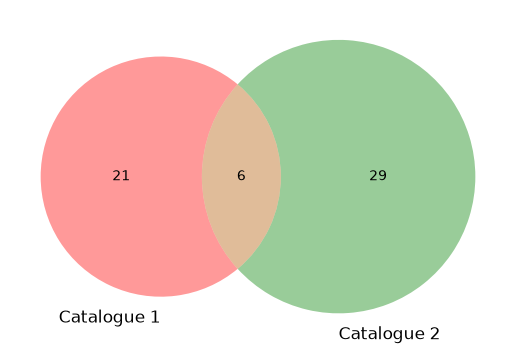

In [12]:
venn2([headings_a, headings_b], ('Catalogue 1', 'Catalogue 2'))
plt.show()
plt.close()

It gives the colorized Venn diagram. The circles and its intersection contain the number of subjects, but not the subjects themselves.

However as the library is based on pyplot, we can add an annotation with `plt.annotate()`. We can create a text box somewhere around the circles, and list the subjects there. There is a problem though: we can transform the list of subjects into a text separated by new lines or by commas, but if they have several elements the annotation will be too high or wide. So we are going to create a new function `format_lines` that mixes the two separators, and creates a list of maximum N character wide lines.

In [13]:
def format_lines(items, max_width=60):
    """
    Arrange a list of strings into a set of lines separated by line breaks.

    Parameters                              
    ----------
    items : list
        a list of strings
    max_width : int
        the maximum width of a line in characters (default is 60)
    """
    lines = []
    line = ''
    for item in items:
        item = re.sub(r'\.$', '', item)
        if len(lines) != 0 or line != '':
            line = line + ','
        for word in item.split():
            if len(line) + len(word) > max_width:
                lines.append(line)
                line = word
            else:
                if line == '':
                    line = word
                else:
                    line = line + ' ' + word
    if line != '':
        lines.append(line)

    return '\n'.join(lines)

With that we can create an annotated Venn diagram:

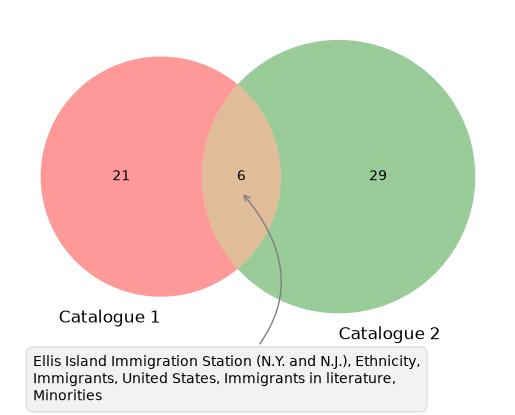

In [14]:
venn_diagram = venn2([headings_a, headings_b], ('Catalogue 1', 'Catalogue 2'))
plt.annotate(
    text=format_lines(result["shared"], 60),
    xy=venn_diagram.get_label_by_id('11').get_position() - np.array([0, 0.05]),
    xytext=(-150,-150),
    ha='left',
    textcoords='offset points',
    bbox=dict(
        boxstyle='round,pad=0.5',
        fc='gray',
        alpha=0.1),
    arrowprops=dict(
        arrowstyle='->',
        connectionstyle='arc3,rad=0.5',
        color='gray'
    )
)
plt.show()

`venn2()` returns an object representing the diagram, and we can manipulate it by changing labels, colors, line width etc. Now we only want to read the position of the label of the intersection of the two circles. We can access it via `get_label_by_id` passing the identifier `11` that refers to the intersection (the first circle is represented by `10`, and by `01` the second). [plt.annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html#matplotlib.axes.Axes.annotate) provides a number of properties. `xy` is the point we want to annotate, `text` contains the annotation text, `xstext` provides a position of the annotation, `textcoords` specifies how this position should be interpreted (here `offset points` means that xytext is a relative position from the annotated point), and `ha` instructs the horizontal alignment. With `bbox` we set the style of the bounding box: it should have a gray foreground color, rounded corner, and a bit opacity. Similarly, `arrowprops` sets the style of the arrow from the annotation to the annotated point, this time is a one direction, grey, curved arrow. As during the previous plot creations we save the plot with a narrow margin and remove references.